# MCES Solver Benchmark Analysis

Compares solvers (`default`, `CPLEX_PY`, `HiGHS_CMD`) across thread counts (1, 2, 4, 8, 12, 16, 24) and mass ranges.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import re
import warnings
warnings.filterwarnings('ignore')

# ── Configuration ────────────────────────────────────────────────────────────
# folder containing all result CSVs
DATA_DIR = Path('../../example/Solvers_output')

SOLVERS       = ['default', 'CPLEX_PY', 'HiGHS_CMD']
THREADS_LIST  = [1, 2, 4, 8]
MASS_RANGES   = [(0,200),(200,300),(300,500),(500,800),(800,1000)]

PALETTE = {s: c for s, c in zip(SOLVERS, sns.color_palette('tab10', len(SOLVERS)))}
sns.set_theme(style='whitegrid', font_scale=1.1)

print('Configuration loaded.')

Configuration loaded.


## 1 · Load all CSV files

In [5]:
PATTERN = re.compile(
    r'filtered_pairs_(\d+)_(\d+)_(.+?)_threads_(\d+)\.csv$'
)

records = []
missing = []

for (lo, hi) in MASS_RANGES:
    for solver in SOLVERS:
        for t in THREADS_LIST:
            fname = DATA_DIR / f'filtered_pairs_{lo}_{hi}_{solver}_threads_{t}_original.csv'
            if fname.exists():
                df = pd.read_csv(fname)
                df['solver']   = solver
                df['threads']  = t
                df['mass_lo']  = lo
                df['mass_hi']  = hi
                df['mass_range'] = f'{lo}–{hi}'
                records.append(df)
            else:
                missing.append(str(fname.name))

# Also pick up any extra files that match the pattern but weren't in the grid
for p in DATA_DIR.glob('filtered_pairs_*.csv'):
    m = PATTERN.match(p.name)
    if m:
        lo, hi, solver, t = int(m.group(1)), int(m.group(2)), m.group(3), int(m.group(4))
        key = (lo, hi, solver, t)
        already = any(
            (r['mass_lo'].iloc[0]==lo and r['mass_hi'].iloc[0]==hi
             and r['solver'].iloc[0]==solver and r['threads'].iloc[0]==t)
            for r in records if len(r)
        )
        if not already:
            df = pd.read_csv(p)
            df['solver'] = solver; df['threads'] = t
            df['mass_lo'] = lo;    df['mass_hi'] = hi
            df['mass_range'] = f'{lo}–{hi}'
            records.append(df)

if records:
    data = pd.concat(records, ignore_index=True)
    print(f'Loaded {len(records)} files → {len(data):,} total rows')
    print(f'Solvers found : {sorted(data["solver"].unique())}')
    print(f'Threads found : {sorted(data["threads"].unique())}')
    print(f'Mass ranges   : {sorted(data["mass_range"].unique())}')
else:
    raise FileNotFoundError('No matching CSV files found. Check DATA_DIR.')

if missing:
    print(f'\n⚠ {len(missing)} expected files not found (first 10):')
    for f in missing[:10]:
        print(' ', f)

Loaded 60 files → 2,592 total rows
Solvers found : ['CPLEX_PY', 'HiGHS_CMD', 'default']
Threads found : [1, 2, 4, 8]
Mass ranges   : ['0–200', '200–300', '300–500', '500–800', '800–1000']


## 2 · Dataset overview

In [6]:
summary = (
    data.groupby(['solver', 'threads', 'mass_range'])
    .agg(
        total_pairs   = ('pair_id',   'count'),
        skipped       = ('skipped',   'sum'),
        solver_called = ('solverCalled', 'sum'),
        mean_runtime  = ('runtime_sec', 'mean'),
        median_runtime= ('runtime_sec', 'median'),
        mean_dist     = ('distance',   'mean'),
    )
    .reset_index()
)
summary['skip_pct'] = 100 * summary['skipped'] / summary['total_pairs']

print('Summary table (first 15 rows):')
display(summary.head(15).round(4))

Summary table (first 15 rows):


,solver,threads,mass_range,total_pairs,skipped,solver_called,mean_runtime,median_runtime,mean_dist,skip_pct
0,CPLEX_PY,1,0–200,7,0,1,5.2287,4.3255,12.0000,0.0000
1,CPLEX_PY,1,200–300,7,0,0,2.2120,2.0867,16.1429,0.0000
2,CPLEX_PY,1,300–500,16,0,1,2.4811,2.0990,16.0000,0.0000
3,CPLEX_PY,1,500–800,47,0,25,4.7260,3.1528,12.0426,0.0000
4,CPLEX_PY,1,800–1000,139,1,71,63.1462,3.7464,13.4601,0.7194
5,CPLEX_PY,2,0–200,7,0,1,2.7135,2.2284,12.0000,0.0000
6,CPLEX_PY,2,200–300,7,0,0,2.0119,1.7804,16.1429,0.0000
7,CPLEX_PY,2,300–500,16,0,1,1.9362,1.8499,16.0000,0.0000
8,CPLEX_PY,2,500–800,47,0,25,4.6350,3.8442,12.0426,0.0000
9,CPLEX_PY,2,800–1000,139,5,68,10.5704,3.2212,13.6082,3.5971


## 3 · Overall fastest solver (mean runtime per pair)

,Mean (s),Median (s),Std,N pairs
solver,,,,
HiGHS_CMD,13.9300,2.1421,20.8770,864
CPLEX_PY,18.6968,2.6460,277.3988,864
default,37.7719,3.1833,251.2876,864


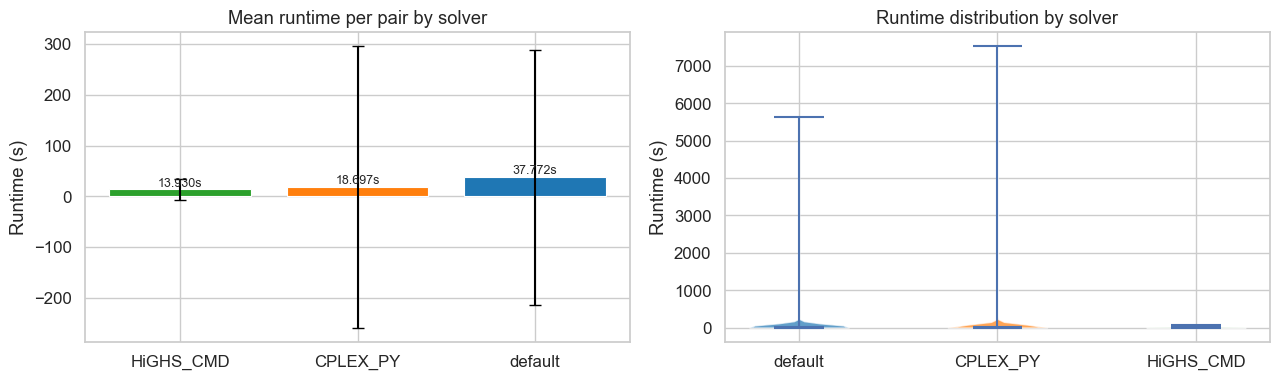


→ Fastest solver overall: HiGHS_CMD


In [7]:
overall = (
    data.groupby('solver')['runtime_sec']
    .agg(['mean','median','std','count'])
    .rename(columns={'mean':'Mean (s)','median':'Median (s)','std':'Std','count':'N pairs'})
    .sort_values('Mean (s)')
)
display(overall.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar: mean runtime
ax = axes[0]
bars = ax.bar(overall.index, overall['Mean (s)'],
              color=[PALETTE[s] for s in overall.index], edgecolor='white', linewidth=0.8)
ax.errorbar(overall.index, overall['Mean (s)'],
            yerr=overall['Std'], fmt='none', color='black', capsize=4)
ax.set_title('Mean runtime per pair by solver')
ax.set_ylabel('Runtime (s)')
ax.set_xlabel('')
for bar, val in zip(bars, overall['Mean (s)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}s', ha='center', va='bottom', fontsize=9)

# Violin: distribution
ax = axes[1]
solvers_present = [s for s in SOLVERS if s in data['solver'].unique()]
parts = ax.violinplot(
    [data.loc[data['solver']==s,'runtime_sec'].dropna().values for s in solvers_present],
    showmedians=True
)
for i, (body, s) in enumerate(zip(parts['bodies'], solvers_present)):
    body.set_facecolor(PALETTE[s])
    body.set_alpha(0.7)
ax.set_xticks(range(1, len(solvers_present)+1))
ax.set_xticklabels(solvers_present)
ax.set_title('Runtime distribution by solver')
ax.set_ylabel('Runtime (s)')

plt.tight_layout()
plt.savefig('01_overall_solver_speed.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n→ Fastest solver overall:', overall.index[0])

## 4 · Skipped pairs per solver

,total,skipped,skip_pct
solver,,,
CPLEX_PY,864,8,0.93
HiGHS_CMD,864,108,12.50
default,864,201,23.26


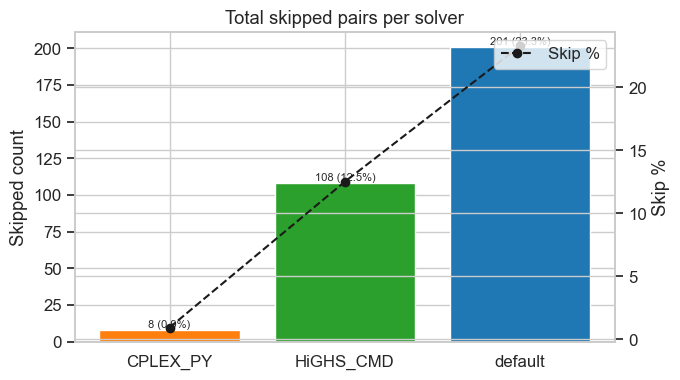

In [8]:
skip_solver = (
    data.groupby('solver')
    .agg(total=('pair_id','count'), skipped=('skipped','sum'))
    .assign(skip_pct=lambda x: 100*x['skipped']/x['total'])
)
display(skip_solver.round(2))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(skip_solver.index, skip_solver['skipped'],
              color=[PALETTE[s] for s in skip_solver.index])
ax2 = ax.twinx()
ax2.plot(skip_solver.index, skip_solver['skip_pct'],
         'k--o', markersize=6, label='Skip %')
ax2.set_ylabel('Skip %')
ax.set_title('Total skipped pairs per solver')
ax.set_ylabel('Skipped count')
ax.set_xlabel('')
for bar, (_, row) in zip(bars, skip_solver.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{int(row['skipped'])} ({row['skip_pct']:.1f}%)",
            ha='center', va='bottom', fontsize=8)
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('02_skipped_by_solver.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 · Does increasing threads reduce skipped pairs?

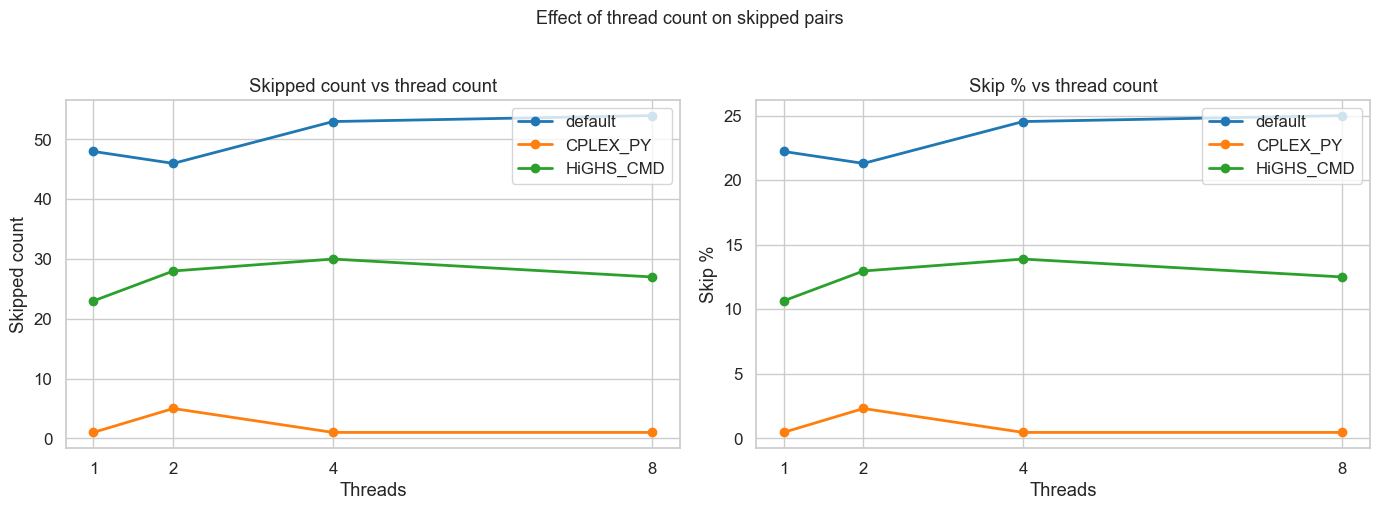

In [9]:
skip_threads = (
    data.groupby(['solver','threads'])
    .agg(total=('pair_id','count'), skipped=('skipped','sum'))
    .assign(skip_pct=lambda x: 100*x['skipped']/x['total'])
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, label in zip(axes, ['skipped','skip_pct'], ['Skipped count','Skip %']):
    for solver in solvers_present:
        sub = skip_threads[skip_threads['solver']==solver].sort_values('threads')
        if sub.empty:
            continue
        ax.plot(sub['threads'], sub[metric], marker='o',
                label=solver, color=PALETTE[solver], linewidth=2)
    ax.set_title(f'{label} vs thread count')
    ax.set_xlabel('Threads')
    ax.set_ylabel(label)
    ax.set_xticks(THREADS_LIST)
    ax.legend()

plt.suptitle('Effect of thread count on skipped pairs', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('03_skip_vs_threads.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 · Does increasing threads improve runtime? (performance scaling)

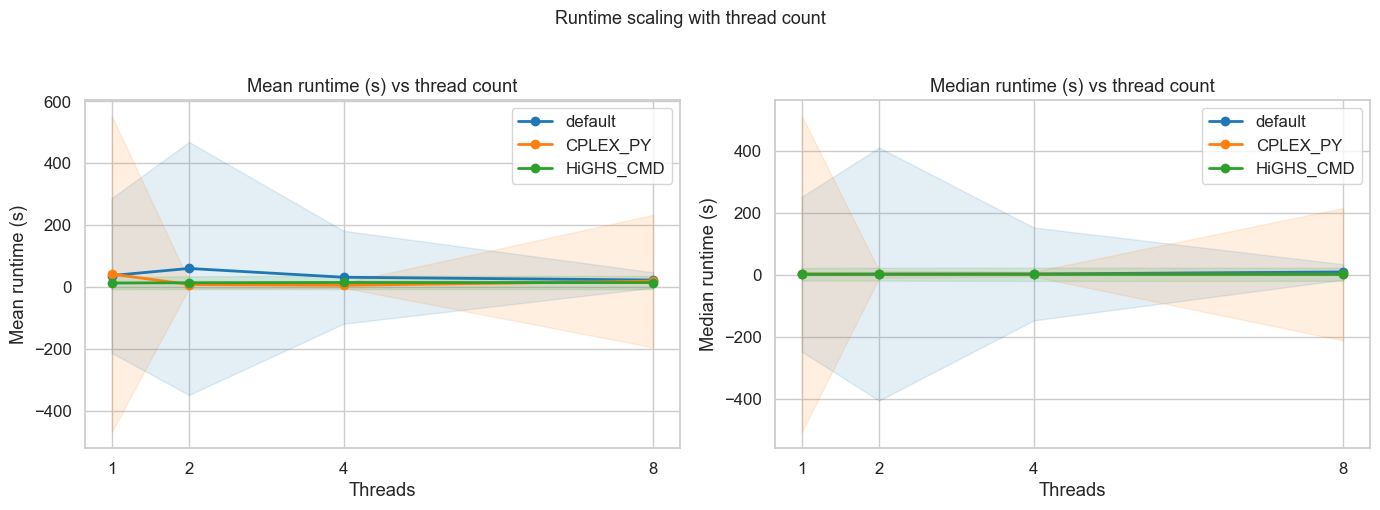

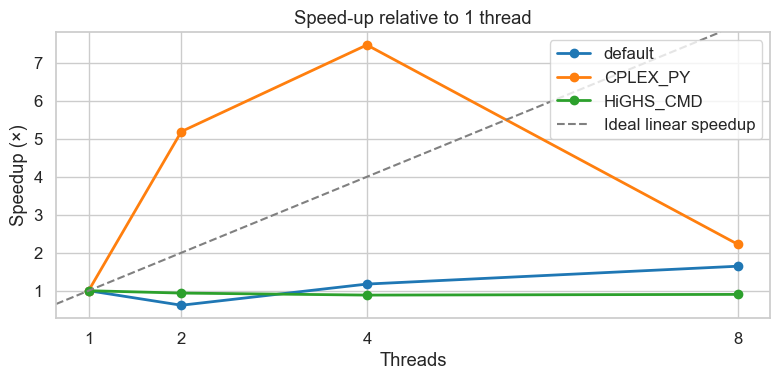

In [10]:
rt_threads = (
    data.groupby(['solver','threads'])['runtime_sec']
    .agg(['mean','median','std'])
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, label in zip(axes, ['mean','median'], ['Mean runtime (s)','Median runtime (s)']):
    for solver in solvers_present:
        sub = rt_threads[rt_threads['solver']==solver].sort_values('threads')
        if sub.empty:
            continue
        ax.plot(sub['threads'], sub[metric], marker='o',
                label=solver, color=PALETTE[solver], linewidth=2)
        ax.fill_between(sub['threads'],
                        sub[metric]-sub['std'], sub[metric]+sub['std'],
                        alpha=0.12, color=PALETTE[solver])
    ax.set_title(f'{label} vs thread count')
    ax.set_xlabel('Threads')
    ax.set_ylabel(label)
    ax.set_xticks(THREADS_LIST)
    ax.legend()

plt.suptitle('Runtime scaling with thread count', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('04_runtime_vs_threads.png', dpi=150, bbox_inches='tight')
plt.show()

# Speed-up relative to 1 thread
if 1 in data['threads'].unique():
    base = rt_threads[rt_threads['threads']==1][['solver','mean']].rename(columns={'mean':'base'})
    speedup = rt_threads.merge(base, on='solver')
    speedup['speedup'] = speedup['base'] / speedup['mean']

    fig, ax = plt.subplots(figsize=(8, 4))
    for solver in solvers_present:
        sub = speedup[speedup['solver']==solver].sort_values('threads')
        if sub.empty:
            continue
        ax.plot(sub['threads'], sub['speedup'], marker='o',
                label=solver, color=PALETTE[solver], linewidth=2)
    ax.axline((1,1), slope=1, linestyle='--', color='gray', label='Ideal linear speedup')
    ax.set_title('Speed-up relative to 1 thread')
    ax.set_xlabel('Threads')
    ax.set_ylabel('Speedup (×)')
    ax.set_xticks(THREADS_LIST)
    ax.legend()
    plt.tight_layout()
    plt.savefig('05_speedup.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7 · Are MCES distances consistent across solvers when ILP is called?

ILP-solver rows: 875 across solvers: ['default' 'CPLEX_PY' 'HiGHS_CMD']

Distance pivot sample (ILP pairs):


solver,CPLEX_PY,HiGHS_CMD,default
pair_id,,,
964,10.0,10.0,10.0
1073,6.0,NaN,NaN
1879,4.0,4.0,4.0
3585,4.0,4.0,4.0
7023,6.0,6.0,10.0
7405,6.0,NaN,NaN
7894,4.0,4.0,4.0
8547,10.0,NaN,NaN
11417,4.0,4.0,4.0



Pairs with all solvers agreeing on distance: 24/56 (42.9%)


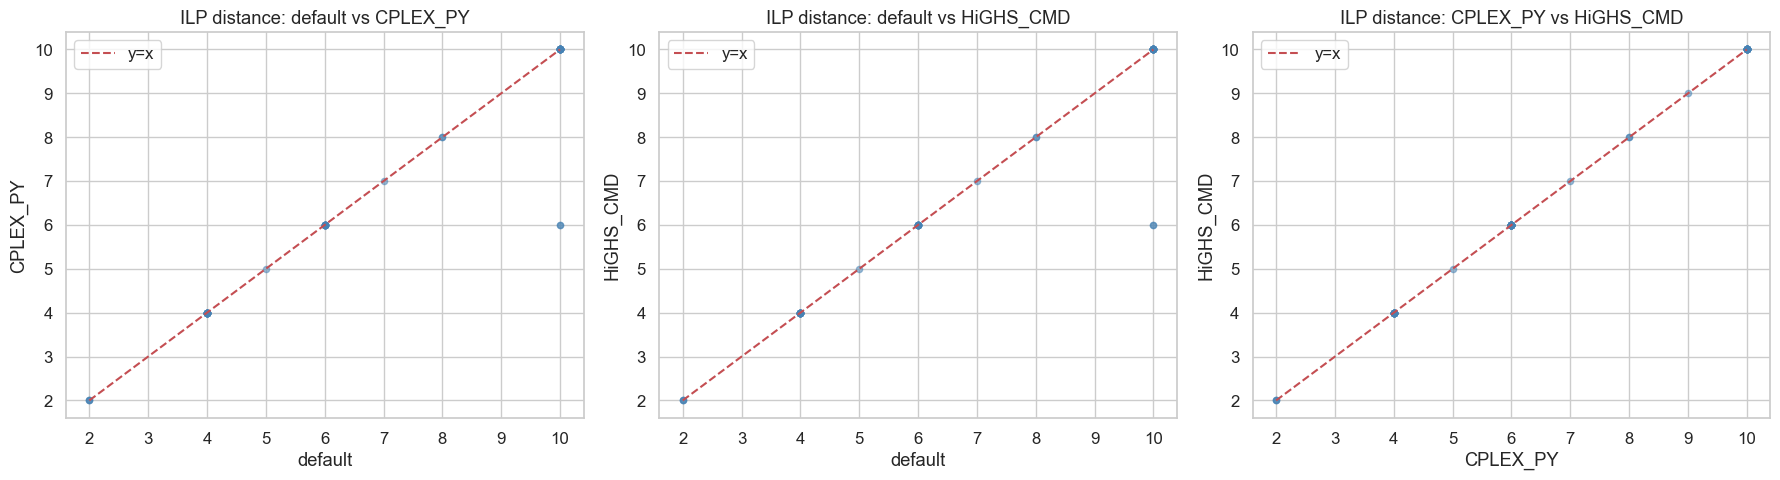

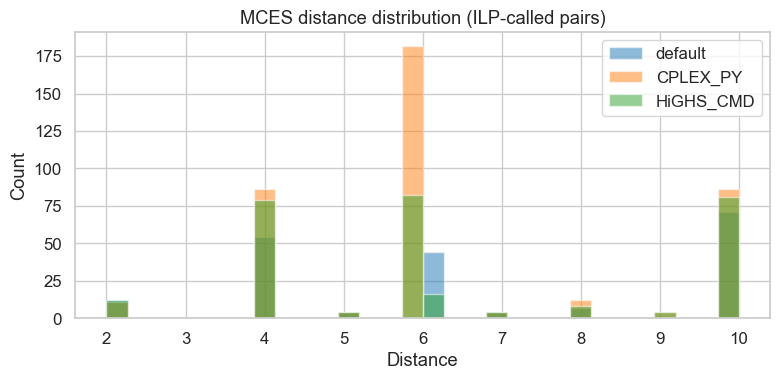

In [11]:
ilp_rows = data[data['solverCalled'] == 1].copy()

if ilp_rows.empty:
    print('No ILP-solver calls found in the loaded data.')
else:
    print(f'ILP-solver rows: {len(ilp_rows):,} across solvers: {ilp_rows["solver"].unique()}')

    # Per-pair distance agreement
    dist_pivot = (
        ilp_rows.groupby(['pair_id','solver'])['distance']
        .first()
        .unstack('solver')
    )
    print('\nDistance pivot sample (ILP pairs):')
    display(dist_pivot.head(10).round(4))

    solver_cols = [s for s in SOLVERS if s in dist_pivot.columns]
    if len(solver_cols) >= 2:
        pairs_all = dist_pivot.dropna(subset=solver_cols)
        n_agree   = (pairs_all[solver_cols].nunique(axis=1) == 1).sum()
        n_total   = len(pairs_all)
        print(f'\nPairs with all solvers agreeing on distance: {n_agree}/{n_total}',
              f'({100*n_agree/n_total:.1f}%)' if n_total else '')

        # Pairwise scatter
        combos = [(solver_cols[i], solver_cols[j])
                  for i in range(len(solver_cols)) for j in range(i+1,len(solver_cols))]
        if combos:
            fig, axes = plt.subplots(1, len(combos), figsize=(6*len(combos), 5))
            if len(combos) == 1:
                axes = [axes]
            for ax, (s1, s2) in zip(axes, combos):
                sub = dist_pivot[[s1,s2]].dropna()
                ax.scatter(sub[s1], sub[s2], alpha=0.5, s=20, color='steelblue')
                lims = [min(sub.min()), max(sub.max())]
                ax.plot(lims, lims, 'r--', linewidth=1.5, label='y=x')
                ax.set_xlabel(s1); ax.set_ylabel(s2)
                ax.set_title(f'ILP distance: {s1} vs {s2}')
                ax.legend()
            plt.tight_layout()
            plt.savefig('06_distance_agreement.png', dpi=150, bbox_inches='tight')
            plt.show()

    # Distance distribution among ILP pairs
    fig, ax = plt.subplots(figsize=(8, 4))
    for solver in ilp_rows['solver'].unique():
        sub = ilp_rows[ilp_rows['solver']==solver]['distance'].dropna()
        ax.hist(sub, bins=30, alpha=0.5, label=solver, color=PALETTE.get(solver))
    ax.set_title('MCES distance distribution (ILP-called pairs)')
    ax.set_xlabel('Distance')
    ax.set_ylabel('Count')
    ax.legend()
    plt.tight_layout()
    plt.savefig('07_ilp_distance_dist.png', dpi=150, bbox_inches='tight')
    plt.show()

## 8 · Solver performance broken down by mass range

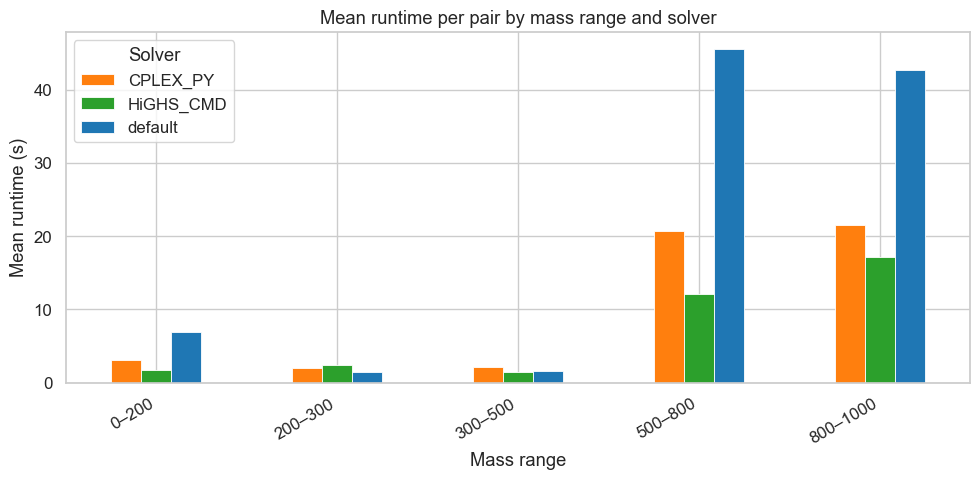

In [12]:
rt_mass = (
    data.groupby(['mass_range','solver'])['runtime_sec']
    .mean()
    .reset_index()
    .pivot(index='mass_range', columns='solver', values='runtime_sec')
)

fig, ax = plt.subplots(figsize=(10, 5))
rt_mass.plot(kind='bar', ax=ax,
             color=[PALETTE.get(s,'gray') for s in rt_mass.columns],
             edgecolor='white', linewidth=0.6)
ax.set_title('Mean runtime per pair by mass range and solver')
ax.set_xlabel('Mass range')
ax.set_ylabel('Mean runtime (s)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Solver')
plt.tight_layout()
plt.savefig('08_runtime_by_mass_range.png', dpi=150, bbox_inches='tight')
plt.show()

## 9 · Heatmap: mean runtime (solver × threads)

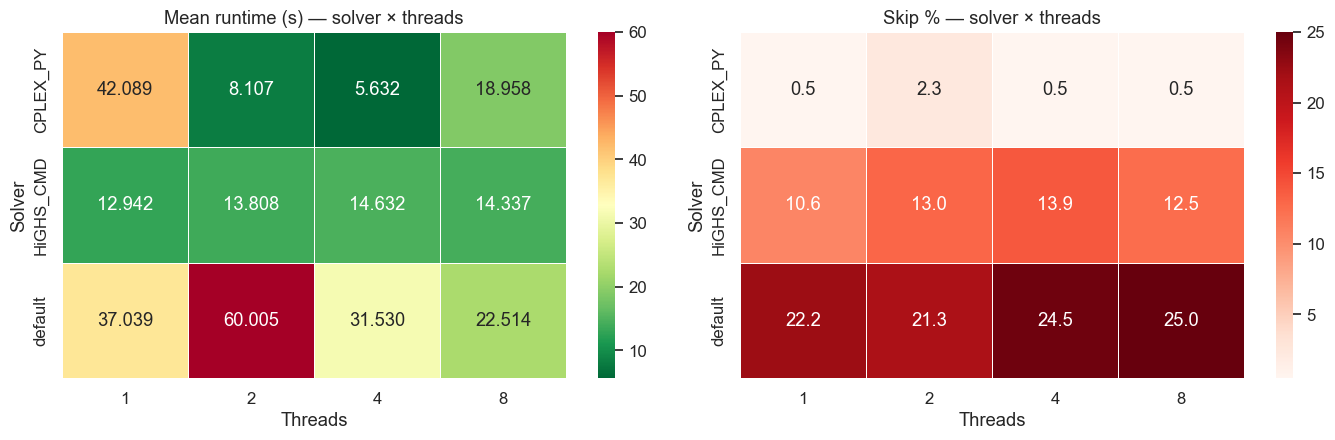

In [13]:
pivot_rt = (
    data.groupby(['solver','threads'])['runtime_sec']
    .mean()
    .unstack('threads')
)

fig, axes = plt.subplots(1, 2, figsize=(14, max(3, len(pivot_rt)*1.2+1)))

# Runtime heatmap
sns.heatmap(pivot_rt, ax=axes[0], annot=True, fmt='.3f',
            cmap='RdYlGn_r', linewidths=0.4, linecolor='white')
axes[0].set_title('Mean runtime (s) — solver × threads')
axes[0].set_xlabel('Threads')
axes[0].set_ylabel('Solver')

# Skip % heatmap
pivot_skip = (
    data.groupby(['solver','threads'])
    .apply(lambda g: 100*g['skipped'].sum()/len(g))
    .unstack('threads')
)
sns.heatmap(pivot_skip, ax=axes[1], annot=True, fmt='.1f',
            cmap='Reds', linewidths=0.4, linecolor='white')
axes[1].set_title('Skip % — solver × threads')
axes[1].set_xlabel('Threads')
axes[1].set_ylabel('Solver')

plt.tight_layout()
plt.savefig('09_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

## 10 · Summary statistics table

In [14]:
final_summary = (
    data.groupby(['solver','threads','mass_range'])
    .agg(
        pairs        = ('pair_id','count'),
        skipped      = ('skipped','sum'),
        skip_pct     = ('skipped', lambda x: round(100*x.sum()/len(x), 2)),
        ilp_calls    = ('solverCalled','sum'),
        mean_rt      = ('runtime_sec','mean'),
        median_rt    = ('runtime_sec','median'),
        p95_rt       = ('runtime_sec', lambda x: x.quantile(0.95)),
        mean_dist    = ('distance','mean'),
    )
    .reset_index()
    .round(4)
)

print('Full summary (all solver/thread/mass-range combos found in data):')
display(final_summary)

final_summary.to_csv('mces_benchmark_summary.csv', index=False)
print('\nSaved to mces_benchmark_summary.csv')

Full summary (all solver/thread/mass-range combos found in data):


,solver,threads,mass_range,pairs,skipped,skip_pct,ilp_calls,mean_rt,median_rt,p95_rt,mean_dist
0,CPLEX_PY,1,0–200,7,0,0.00,1,5.2287,4.3255,10.2481,12.0000
1,CPLEX_PY,1,200–300,7,0,0.00,0,2.2120,2.0867,3.0023,16.1429
2,CPLEX_PY,1,300–500,16,0,0.00,1,2.4811,2.0990,4.7082,16.0000
3,CPLEX_PY,1,500–800,47,0,0.00,25,4.7260,3.1528,13.5135,12.0426
4,CPLEX_PY,1,800–1000,139,1,0.72,71,63.1462,3.7464,31.2612,13.4601
5,CPLEX_PY,2,0–200,7,0,0.00,1,2.7135,2.2284,3.7441,12.0000
6,CPLEX_PY,2,200–300,7,0,0.00,0,2.0119,1.7804,2.7989,16.1429
7,CPLEX_PY,2,300–500,16,0,0.00,1,1.9362,1.8499,2.7477,16.0000
8,CPLEX_PY,2,500–800,47,0,0.00,25,4.6350,3.8442,11.0809,12.0426
9,CPLEX_PY,2,800–1000,139,5,3.60,68,10.5704,3.2212,41.0558,13.6082



Saved to mces_benchmark_summary.csv
